## Task 2 — Student Dataset Preprocessing and Wave Segmentation

Using Python scripts, process the dataset prepared in Task 1:

1. Check the dataset for:
   - duplicates,
   - missing values,
   - data types,
   - anomalous values.

   Perform preprocessing if needed.

2. Split all students into waves.

### Wave criteria
- **Wave 0** — joined the course on or before the course start date
- **Wave 1** — joined within 1 week after the course start date, inclusive
- **Wave 2** — joined from 1 to 2 weeks after the course start date, inclusive
- **Wave 3** — joined from 2 to 3 weeks after the course start date, inclusive
- **Wave 4** — joined from 3 to 4 weeks after the course start date, inclusive
- **Wave 5** — joined 4 or more weeks after the course start date


## Import libraries

In [1766]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

## Load the dataset

In [1767]:
student_df = pd.read_excel("task1_output.xlsx")
student_df.head()

,course_id,course_name,subject_name,subject_type,course_type,course_start_date,student_id,student_last_name,city,is_expelled,student_start_date,available_months,cnt_hw_done_per_course
0,16,Годовой 2к25 стандарт,Social Studies,EGE,Annual,2024-09-16,10001,Markova,Самара,0,2024-07-25 18:04:20,2,9
1,19,Годовой 2к25 стандарт,Russian,EGE,Annual,2024-09-21,10001,Markova,Самара,0,2024-07-25 18:04:20,2,8
2,19,Годовой 2к25 стандарт,Russian,EGE,Annual,2024-09-21,10002,Коваленко,Москва,1,2024-07-25 18:07:04,1,4
3,17,Годовой 2к25 стандарт,English,EGE,Annual,2024-09-20,10003,Драгомирецкий,NaN,0,2024-09-05 19:11:35,0,2
4,21,Годовой 2к25 стандарт,Chemistry,EGE,Annual,2024-09-16,10005,Гусев,Белгород,0,2024-07-26 05:38:40,1,1


In [1768]:
student_df.subject_name.unique()

array(['Social Studies', 'Russian', 'English', 'Chemistry', 'Biology',
       'History', 'Mathematics', 'Literature', 'Russian OGE',
       'Mathematics OGE', 'Biology OGE', 'Social Studies OGE', 'Physics',
       'Basic Mathematics'], dtype=object)

In [1769]:
student_df.shape

(5881, 13)

## Initial data overview


In [1770]:
student_df.describe()

,course_id,student_id,is_expelled,available_months,cnt_hw_done_per_course
count,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000
mean,23.397721,24667.356232,0.059174,2.175310,8.684067
std,14.112984,8642.903710,0.235969,1.734614,6.773033
min,16.000000,10001.000000,0.000000,0.000000,0.000000
25%,16.000000,10989.000000,0.000000,2.000000,3.000000
50%,19.000000,28327.000000,0.000000,2.000000,9.000000
75%,23.000000,30598.000000,0.000000,2.000000,13.000000
max,103.000000,33999.000000,1.000000,10.000000,33.000000


In [1771]:
student_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5881 entries, 0 to 5880
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   course_id               5881 non-null   int64 
 1   course_name             5881 non-null   object
 2   subject_name            5881 non-null   object
 3   subject_type            5881 non-null   object
 4   course_type             5881 non-null   object
 5   course_start_date       5881 non-null   object
 6   student_id              5881 non-null   int64 
 7   student_last_name       5881 non-null   object
 8   city                    5540 non-null   object
 9   is_expelled             5881 non-null   int64 
 10  student_start_date      5881 non-null   object
 11  available_months        5881 non-null   int64 
 12  cnt_hw_done_per_course  5881 non-null   int64 
dtypes: int64(5), object(8)
memory usage: 597.4+ KB


In [1772]:
student_df.describe(include='all')

,course_id,course_name,subject_name,subject_type,course_type,course_start_date,student_id,student_last_name,city,is_expelled,student_start_date,available_months,cnt_hw_done_per_course
count,5881.000000,5881,5881,5881,5881,5881,5881.000000,5881,5540,5881.000000,5881,5881.000000,5881.000000
unique,NaN,11,14,2,2,17,NaN,2880,578,NaN,5087,NaN,NaN
top,NaN,Годовой 2к25 стандарт,Social Studies,EGE,Annual,2024-09-16,NaN,Максимова,Москва,NaN,2024-07-29 09:15:45,NaN,NaN
freq,NaN,4475,1788,5357,5716,2017,NaN,26,781,NaN,4,NaN,NaN
mean,23.397721,NaN,NaN,NaN,NaN,NaN,24667.356232,NaN,NaN,0.059174,NaN,2.175310,8.684067
std,14.112984,NaN,NaN,NaN,NaN,NaN,8642.903710,NaN,NaN,0.235969,NaN,1.734614,6.773033
min,16.000000,NaN,NaN,NaN,NaN,NaN,10001.000000,NaN,NaN,0.000000,NaN,0.000000,0.000000
25%,16.000000,NaN,NaN,NaN,NaN,NaN,10989.000000,NaN,NaN,0.000000,NaN,2.000000,3.000000
50%,19.000000,NaN,NaN,NaN,NaN,NaN,28327.000000,NaN,NaN,0.000000,NaN,2.000000,9.000000
75%,23.000000,NaN,NaN,NaN,NaN,NaN,30598.000000,NaN,NaN,0.000000,NaN,2.000000,13.000000


In [1773]:
sorted(student_df['course_start_date'].unique())

['2024-09-15',
 '2024-09-16',
 '2024-09-17',
 '2024-09-18',
 '2024-09-20',
 '2024-09-21',
 '2024-09-22',
 '2024-09-23',
 '2024-09-25',
 '2024-09-30',
 '2024-10-15',
 '2024-11-13',
 '2024-11-14',
 '2024-11-15',
 '2024-11-18',
 '2024-11-19',
 '2024-11-23']

We analyze courses for the period from September to November 2024.

The dataset was loaded successfully. Each row appears to represent a student-course record and includes course attributes, student attributes, course access dates, and engagement-related metrics.

## Validate data types

Сonvert the data types in the columns to the most appropriate types:

In [1774]:
student_df = student_df.convert_dtypes()

In [1775]:
student_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5881 entries, 0 to 5880
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   course_id               5881 non-null   Int64 
 1   course_name             5881 non-null   string
 2   subject_name            5881 non-null   string
 3   subject_type            5881 non-null   string
 4   course_type             5881 non-null   string
 5   course_start_date       5881 non-null   string
 6   student_id              5881 non-null   Int64 
 7   student_last_name       5881 non-null   string
 8   city                    5540 non-null   string
 9   is_expelled             5881 non-null   Int64 
 10  student_start_date      5881 non-null   string
 11  available_months        5881 non-null   Int64 
 12  cnt_hw_done_per_course  5881 non-null   Int64 
dtypes: Int64(5), string(8)
memory usage: 626.1 KB


Convert date columns to datetime type

In [1776]:
date_cols = ['course_start_date', 'student_start_date']
student_df[date_cols] = student_df[date_cols].apply(pd.to_datetime)
student_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5881 entries, 0 to 5880
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   course_id               5881 non-null   Int64         
 1   course_name             5881 non-null   string        
 2   subject_name            5881 non-null   string        
 3   subject_type            5881 non-null   string        
 4   course_type             5881 non-null   string        
 5   course_start_date       5881 non-null   datetime64[ns]
 6   student_id              5881 non-null   Int64         
 7   student_last_name       5881 non-null   string        
 8   city                    5540 non-null   string        
 9   is_expelled             5881 non-null   Int64         
 10  student_start_date      5881 non-null   datetime64[ns]
 11  available_months        5881 non-null   Int64         
 12  cnt_hw_done_per_course  5881 non-null   Int64   

Convert columns to appropriate data types for further validation and wave assignment. In particular, date columns should be converted to `datetime`, while numeric and text columns should use consistent types.

## Data quality checks

### Check for duplicates

In [1777]:
dups_users = student_df[student_df.duplicated(keep=False)]
dups_users


,course_id,course_name,subject_name,subject_type,course_type,course_start_date,student_id,student_last_name,city,is_expelled,student_start_date,available_months,cnt_hw_done_per_course


No full-row duplicates were found. Duplicate student-course pairs were also checked separately to verify that each row represents a unique student-course record.

In [1778]:
dups_users = student_df[student_df.duplicated(subset=['student_id', 'course_id', 'subject_name'],keep=False)]
dups_users


,course_id,course_name,subject_name,subject_type,course_type,course_start_date,student_id,student_last_name,city,is_expelled,student_start_date,available_months,cnt_hw_done_per_course


In [1779]:
student_df[student_df.duplicated(subset=['student_id', 'course_id'],keep=False)]

,course_id,course_name,subject_name,subject_type,course_type,course_start_date,student_id,student_last_name,city,is_expelled,student_start_date,available_months,cnt_hw_done_per_course


In [1780]:
student_df[student_df.duplicated(subset=['student_id', 'course_id'],keep=False)]['student_id'].unique()

<IntegerArray>
[]
Length: 0, dtype: Int64

I checked both full-row duplicates and duplicate student-course pairs. This helps verify that each row represents a unique student-course record.

### Check for missing values

In [1781]:
missing_data = student_df.isna().sum()
missing_data

course_id                   0
course_name                 0
subject_name                0
subject_type                0
course_type                 0
course_start_date           0
student_id                  0
student_last_name           0
city                      341
is_expelled                 0
student_start_date          0
available_months            0
cnt_hw_done_per_course      0
dtype: int64

In [1782]:
student_df[student_df['student_id'].isna()]

,course_id,course_name,subject_name,subject_type,course_type,course_start_date,student_id,student_last_name,city,is_expelled,student_start_date,available_months,cnt_hw_done_per_course


In [1783]:
student_df[student_df['city'].isna()]['student_id'].nunique()

196

In [1784]:
student_df.loc[student_df['city'].isna()] \
    .groupby('student_id') \
    .size() \
    .reset_index(name='cnt') \
    .sort_values(by='cnt', ascending=False).head()


,student_id,cnt
64,25365,15
6,10065,6
2,10036,5
9,10216,5
13,10276,5


Let's see if there is any data about the city for these students, but for other courses. Perhaps this information is available, but it is simply missing for some course. To do this, let's compare the table for students who do not have a city with the table for students who have information about the city, according to the student's ID.

In [1785]:
students_without_city = student_df.loc[
    student_df['city'].isna(),
    ['student_id', 'student_last_name', 'city']
]

students_with_city = student_df.loc[
    student_df['city'].notna(),
    ['student_id', 'student_last_name', 'city']
]

students_mixed_city = students_without_city.merge(
    students_with_city,
    on='student_id',
    how='inner',
    suffixes=('_missing', '_filled')
)

students_mixed_city

,student_id,student_last_name_missing,city_missing,student_last_name_filled,city_filled


As you can see, there is no information so that we can supplement it.

Missing values were found in the `city` field. To assess whether this information could be recovered, I checked whether the same students had non-missing city values in other course records.

Missing values in `city` most likely reflect incomplete source data rather than an issue that can be fixed from within the dataset, since the same students do not have city information in other records either.

## Review anomalous values

Let's look at possible anomalies in the data.

In [1786]:
short_names = pd.Series(student_df['student_last_name'].unique())
short_names[short_names.str.len() <= 5]

3       Гусев
44      Данил
51       Толк
83      Матяш
86       Gold
91        Fox
112       Абб
118     Ankha
140     Котов
163     Andre
181     Зуева
189     Ирина
228      Nuta
229       Юст
270     Vinas
274     Мороз
283       Тен
284        Ki
296     Пупок
302       Koo
316     Пищик
328       Yun
376     Михно
383      Джун
395       Мис
438     Шимпф
441       Sab
472        Or
476     Собко
499        Че
500     Лушин
507     Комар
511     Пынтя
514     Gerst
517     Шегян
534      Kien
535      Тире
537     Чабан
556     Rakhm
564     Мария
569      Wwnv
576       Fly
577      Vart
585     Кобец
588     Таран
592      Фетт
601     Луцан
612         A
639      VuyS
645        См
648     Мявка
676      Онет
691      Сайб
701      Kkkk
723     Качур
727     Guzik
738     Alone
753       Кот
755        Эл
759      Мося
775         V
781     Мазур
793     Шимко
799     Круть
803     Курта
835        Дл
836     Лысов
837     Gavre
845     Талах
847     Костя
855       You
861   

Some `student_last_name` values are unusually short (for example, `Koo`, `Ki`, `Fox`, `Gold`). These may reflect nicknames. Since this field is descriptive and is not used in calculations, no correction was applied.

Let's check if there are students studying both EGE and OGE subjects at the same time.

In [1787]:
students_2_types_subj = student_df.groupby('student_id') \
    .agg(subject_type_nunique=('subject_type', 'nunique')) \
    .query('subject_type_nunique == 2').reset_index()

students_2_types_subj

,student_id,subject_type_nunique
0,10068,2
1,10119,2
2,10185,2
3,10338,2
4,10379,2
5,25271,2
6,25331,2
7,25365,2
8,25382,2
9,25866,2


In [1788]:
student_df[student_df['student_id'].isin(students_2_types_subj['student_id'])] \
    .groupby(['student_id', 'subject_type'])['subject_name'] \
    .nunique() \
    .reset_index(name='subject_cnt') \
    .sort_values(by=['student_id', 'subject_type'])

,student_id,subject_type,subject_cnt
0,10068,EGE,1
1,10068,OGE,4
2,10119,EGE,1
3,10119,OGE,2
4,10185,EGE,2
5,10185,OGE,2
6,10338,EGE,1
7,10338,OGE,3
8,10379,EGE,1
9,10379,OGE,4


In [1789]:
students_2_types_subj['student_id'].nunique()

13

Interestingly, 13 students appear in both the EGE and OGE groups. This may be because some students who are currently preparing for the OGE have already started preparing for the EGE too.
 Since this does not affect the current task, I kept these records unchanged

#### Review of homework completion distribution

In [1790]:
student_df[['cnt_hw_done_per_course']].describe()

,cnt_hw_done_per_course
count,5881.0
mean,8.684067
std,6.773033
min,0.0
25%,3.0
50%,9.0
75%,13.0
max,33.0


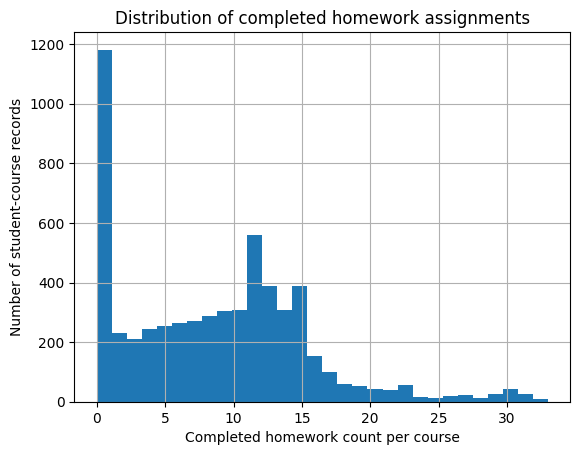

In [1791]:
student_df['cnt_hw_done_per_course'].hist(bins=30)
plt.xlabel('Completed homework count per course')
plt.ylabel('Number of student-course records')
plt.title('Distribution of completed homework assignments')
plt.show()

In [1792]:
zero_hw_share = (student_df['cnt_hw_done_per_course'] == 0).mean()
zero_hw_share_pct = (student_df['cnt_hw_done_per_course'] == 0).mean() * 100

print(f"Share of student-course records with zero completed homework: {zero_hw_share_pct:.2f}%")

Share of student-course records with zero completed homework: 16.41%


The distribution of completed homework assignments is uneven and right-skewed. About 16.41% of student-course records have zero completed homework, which points to a noticeable group of low-engagement students. Most records fall into the lower and middle range, while a relatively small number of students show much higher homework activity.

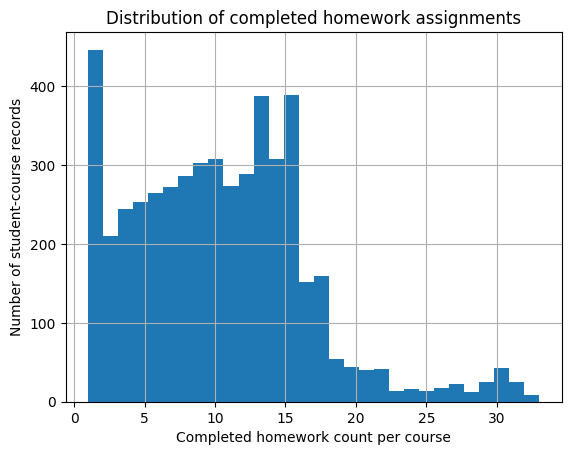

In [1793]:
student_df[student_df['cnt_hw_done_per_course'] > 0]['cnt_hw_done_per_course'].hist(bins=30)
plt.xlabel('Completed homework count per course')
plt.ylabel('Number of student-course records')
plt.title('Distribution of completed homework assignments')
plt.show()

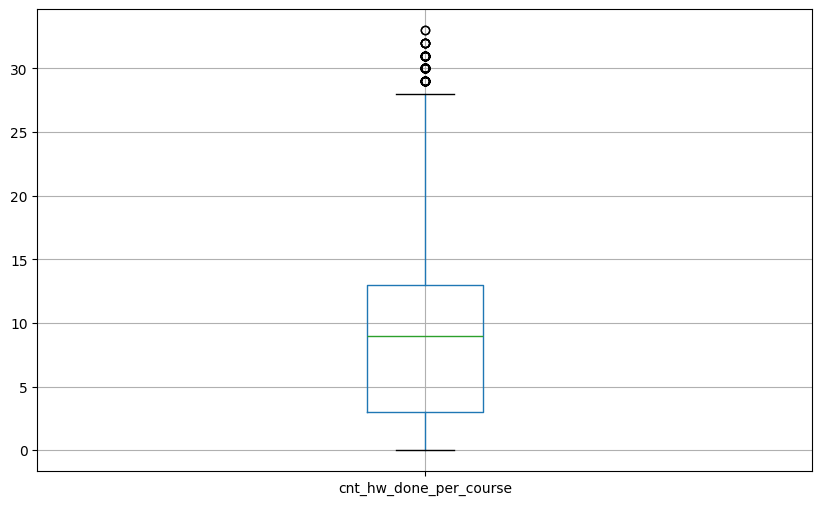

In [1794]:
plt.figure(figsize=(10, 6))
student_df.boxplot('cnt_hw_done_per_course')
plt.show()

The boxplot confirms that the distribution of completed homework assignments is right-skewed. The median is around 9 assignments, and the middle 50% of observations lies approximately between 3 and 13. Several upper outliers are also present, indicating a small group of students with much higher homework activity.

In [1795]:
Q1 = student_df['cnt_hw_done_per_course'].quantile(0.25)
Q3 = student_df['cnt_hw_done_per_course'].quantile(0.75)
IQR = Q3 - Q1
outliers = Q3 + 1.5 * IQR
outliers

np.float64(28.0)

In [1796]:
p95 = np.percentile(student_df['cnt_hw_done_per_course'], 95)
p10 = np.percentile(student_df['cnt_hw_done_per_course'], 10)
p95

np.float64(20.0)

In [1797]:
p10

np.float64(0.0)

To better understand the tails of the distribution, I calculated both the IQR-based upper bound and selected percentiles. 

The upper bound for high-value outliers is 28 completed homework assignments, while the 95th percentile is 20. This means that values above 20 are already relatively rare, and values above 28 can be treated as clear upper outliers. 

At the lower end, the 10th percentile equals 0, which confirms the presence of a noticeable group of student-course records with no completed homework assignments.

#### Students with no completed homework assignments

Next, I focus on students with very low homework activity, since this group may represent low engagement or students at risk of non-continuation.

In [1798]:
student_df[(student_df['cnt_hw_done_per_course'] == 0) & (student_df['is_expelled'] == 1)]['student_id'].count()

np.int64(280)

In [1799]:
student_df[(student_df['cnt_hw_done_per_course'] == 0) & (student_df['is_expelled'] == 0)]['student_id'].count()

np.int64(685)

Among students with no completed homework assignments, many are still not expelled. This suggests that zero homework completion does not automatically indicate churn or expulsion.

In [1800]:
student_df[(student_df['cnt_hw_done_per_course'] == 0) & (student_df['is_expelled'] == 1)].head()

,course_id,course_name,subject_name,subject_type,course_type,course_start_date,student_id,student_last_name,city,is_expelled,student_start_date,available_months,cnt_hw_done_per_course
486,16,Годовой 2к25 стандарт,Social Studies,EGE,Annual,2024-09-16,10011,Ищенко,Анива,1,2024-07-26 10:26:56,0,0
487,24,В погоне за пятеркой 2К25 стандарт,Basic Mathematics,EGE,Annual,2024-09-17,10011,Ищенко,Анива,1,2024-07-26 10:26:56,0,0
488,36,Годовой курс 2к25,Social Studies OGE,OGE,Annual,2024-09-30,10013,Дьякова,Новосибирск,1,2024-07-26 08:58:04,0,0
491,22,Годовой 2к25 стандарт,Literature,EGE,Annual,2024-09-17,10024,Имамутдинова,Туймазы,1,2024-07-26 12:55:29,0,0
492,16,Годовой 2к25 стандарт,Social Studies,EGE,Annual,2024-09-16,10024,Имамутдинова,Туймазы,1,2024-07-26 12:55:29,0,0


Most students who did not complete any homework assignments were still not expelled. Some expelled students still have 1 available month of classes, which may indicate that expulsion can happen for reasons other than simply using up all available course time. Expulsion does not appear to be concentrated in any particular course or subject, as such cases are observed across different courses and subjects.

In [1801]:
student_df[(student_df['cnt_hw_done_per_course'] == 0) & (student_df['is_expelled'] == 1)]['available_months'].unique()

<IntegerArray>
[0, 1]
Length: 2, dtype: Int64

In [1802]:
student_df[(student_df['cnt_hw_done_per_course'] == 0) & (student_df['is_expelled'] == 0)& (student_df['available_months'] == 1)].head()

,course_id,course_name,subject_name,subject_type,course_type,course_start_date,student_id,student_last_name,city,is_expelled,student_start_date,available_months,cnt_hw_done_per_course
489,91,Погоня за мечтой 2к25,Mathematics,EGE,Annual 2.0,2024-11-15,10016,Бойсариева,<NA>,0,2024-10-30 18:03:32,1,0
493,19,Годовой 2к25 стандарт,Russian,EGE,Annual,2024-09-21,10024,Имамутдинова,Туймазы,0,2024-07-26 12:55:30,1,0
494,24,В погоне за пятеркой 2К25 стандарт,Basic Mathematics,EGE,Annual,2024-09-17,10028,Денисова,Ханты-Мансийск,0,2024-08-31 07:37:07,1,0
495,16,Годовой 2к25 стандарт,Social Studies,EGE,Annual,2024-09-16,10029,Болотин,Санкт-Петербург,0,2024-07-26 19:05:27,1,0
498,19,Годовой 2к25 стандарт,Russian,EGE,Annual,2024-09-21,10036,Цветаев,<NA>,0,2024-07-26 14:56:55,1,0


In [1803]:
student_df[(student_df['cnt_hw_done_per_course'] == 0) & (student_df['is_expelled'] == 0)& (student_df['available_months'] == 0)]['subject_name'].unique()

<StringArray>
['Social Studies OGE', 'Russian OGE']
Length: 2, dtype: string

For some reason, some students who have not completed any hw and who have not been expelled do not have open months of the course. This is typical for students in the subjects: Social Studies, OGE, Russian OGE

In [1804]:
student_df[student_df['subject_type'] == 'OGE']['subject_name'].unique()

<StringArray>
['Russian OGE', 'Mathematics OGE', 'Biology OGE', 'Social Studies OGE']
Length: 4, dtype: string

#### High-value outliers in homework completion

In [1805]:
student_df[student_df['cnt_hw_done_per_course'] > p95].head(10)

,course_id,course_name,subject_name,subject_type,course_type,course_start_date,student_id,student_last_name,city,is_expelled,student_start_date,available_months,cnt_hw_done_per_course
33,25,Годовой 2к25 стандарт,Biology,EGE,Annual,2024-09-17,10033,Боровинская,Екатеринбург,0,2024-07-26 14:08:17,2,31
38,17,Годовой 2к25 стандарт,English,EGE,Annual,2024-09-20,10038,Уразова,Пермь,0,2024-07-26 15:45:44,2,29
73,17,Годовой 2к25 стандарт,English,EGE,Annual,2024-09-20,10070,Степанова,Красноярск,0,2024-08-16 15:00:31,2,30
74,22,Годовой 2к25 стандарт,Literature,EGE,Annual,2024-09-17,10072,Аглиева,Салават,0,2024-07-27 13:49:46,2,21
81,17,Годовой 2к25 стандарт,English,EGE,Annual,2024-09-20,10079,Искандарова,Пермь,0,2024-07-27 11:35:25,2,30
87,25,Годовой 2к25 стандарт,Biology,EGE,Annual,2024-09-17,10082,Абдувелиева,Симферополь,0,2024-08-21 11:39:01,9,27
89,22,Годовой 2к25 стандарт,Literature,EGE,Annual,2024-09-17,10084,Моторова,Красногорск,0,2024-07-27 13:16:04,3,22
98,23,Годовой 2К25 стандарт с Машей,Mathematics,EGE,Annual,2024-09-20,10088,Ваулина,Шебекино,0,2024-07-27 16:52:28,9,21
104,17,Годовой 2к25 стандарт,English,EGE,Annual,2024-09-20,10094,Солнышко,Москва,0,2024-09-13 14:19:48,9,25
112,22,Годовой 2к25 стандарт,Literature,EGE,Annual,2024-09-17,10097,Назарова,Пермь,0,2024-07-30 17:04:51,2,22


Among the records in the top 5% by completed homework count, there is a noticeable difference between students with 2 available months and those with 9 available months. This suggests that homework counts are influenced not only by student engagement, but also by how much of the course has already been opened.

To interpret high values correctly, it would be helpful to know how many homework assignments are available at each stage of the course for each subject. Without this context, some high values may appear unusual even though they are actually reasonable.

Using the IQR rule, 101 student-course records are classified as upper outliers.

In [1806]:
student_df[(student_df['cnt_hw_done_per_course'] > outliers)]['student_id'].nunique()

101

In [1807]:
before_start = student_df[(student_df['cnt_hw_done_per_course'] > outliers)&(student_df['student_start_date'] < student_df['course_start_date'])]['student_id'].nunique()
on_start = student_df[(student_df['cnt_hw_done_per_course'] > outliers)&(student_df['student_start_date'] == student_df['course_start_date'])]['student_id'].nunique()
after_start = student_df[(student_df['cnt_hw_done_per_course'] > outliers)&(student_df['student_start_date'] > student_df['course_start_date'])]['student_id'].nunique()

print(f'Number of students who joined before the course start date: {before_start}')
print(f'Number of students who joined on the course start date: {on_start}')
print(f'Number of students who joined after the course start date: {after_start}')

Number of students who joined before the course start date: 74
Number of students who joined on the course start date: 0
Number of students who joined after the course start date: 27


Let's check if among the expelled students there are those who were among the outliers in terms of the number of completed tasks.

In [1808]:
student_df[(student_df['cnt_hw_done_per_course'] > outliers)&(student_df['is_expelled'] == 1)].head(10)

,course_id,course_name,subject_name,subject_type,course_type,course_start_date,student_id,student_last_name,city,is_expelled,student_start_date,available_months,cnt_hw_done_per_course
1387,25,Годовой 2к25 стандарт,Biology,EGE,Annual,2024-09-17,10959,Аистова,Киров,1,2024-08-24 11:24:27,1,30


One of the students with a high number of completed assignments was expelled. This may reflect early access, longer participation, or course-specific differences in homework volume rather than data quality issues.

In [1809]:
max_cnt_hw = student_df['cnt_hw_done_per_course'].max()

In [1810]:
student_df[(student_df['cnt_hw_done_per_course'] == max_cnt_hw)].head(10).sort_values(by='available_months', ascending=False)

,course_id,course_name,subject_name,subject_type,course_type,course_start_date,student_id,student_last_name,city,is_expelled,student_start_date,available_months,cnt_hw_done_per_course
1317,17,Годовой 2к25 стандарт,English,EGE,Annual,2024-09-20,10906,Никогосян,Яхрома,0,2024-08-06 08:48:41,3,33
1334,17,Годовой 2к25 стандарт,English,EGE,Annual,2024-09-20,10917,Максимова,Бор,0,2024-08-06 10:27:43,2,33


Two students completed the largest number of tasks among all. Their access to the course was opened earlier than the official start date, and on the same day. Perhaps they have access to all tasks at once.

A small number of very high homework counts are present in the dataset. These values appear unusual, but they may reflect longer participation, higher course intensity, or subject-specific assignment structure rather than obvious data errors.

Let's build a box plot according to the number of completed hw for each subject. This approach will help you quickly detect items with an unusually high or low number of completed tasks, which may indicate anomalies.

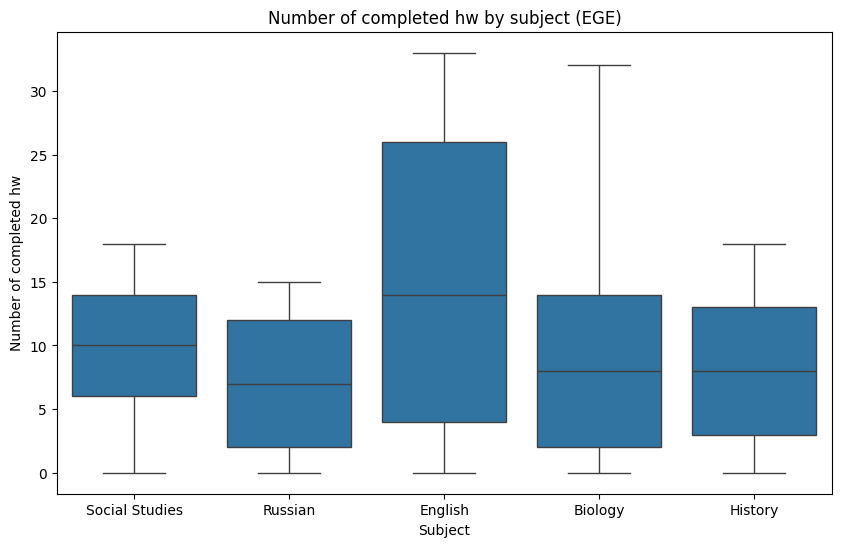

In [1811]:
EGE_cols1 = ['Social Studies', 'English', 'History', 'Russian', 'Biology']
EGE_cols2 = ['Physics', 'Chemistry', 'Literature', 'Mathematics', 'Basic Mathematics']
OGE_cols = ['Social Studies OGE', 'Russian OGE', 'Mathematics OGE', 'Biology OGE']

plt.figure(figsize=(10, 6))
sns.boxplot(x='subject_name', y='cnt_hw_done_per_course', data=student_df[student_df['subject_name'].isin(EGE_cols1)])
plt.title('Number of completed hw by subject (EGE)')
plt.xlabel('Subject')
plt.ylabel('Number of completed hw')
plt.show()

Biology appears to have several high-value outliers in the number of completed homework assignments, which may indicate either higher engagement among a subset of students or subject-specific differences in assignment structure.

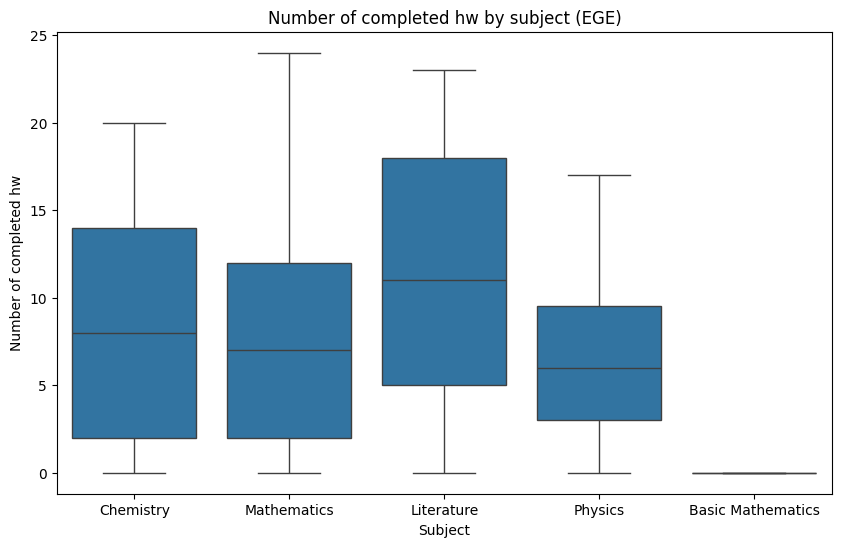

In [1812]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='subject_name', y='cnt_hw_done_per_course', data=student_df[student_df['subject_name'].isin(EGE_cols2)])
plt.title('Number of completed hw by subject (EGE)')
plt.xlabel('Subject')
plt.ylabel('Number of completed hw')
plt.show()

There's also high variability in chemistry and literature, and a long upper limit in mathematics. In basic mathematics, the number of completed homework assignments for all students suddenly equals 0:

In [1813]:
student_df[student_df['subject_name']=='Basic Mathematics']['cnt_hw_done_per_course'].unique()

<IntegerArray>
[0]
Length: 1, dtype: Int64

Perhaps, since it is a non-core subject, students with low motivation or who are not interested in mathematics study here.

In [1814]:
student_df[student_df['subject_name']=='Basic Mathematics']['student_id'].nunique()

177

In [1815]:
student_df[student_df['subject_name']=='Mathematics']['student_id'].nunique()

497

Much fewer students study basic mathematics than advanced mathematics

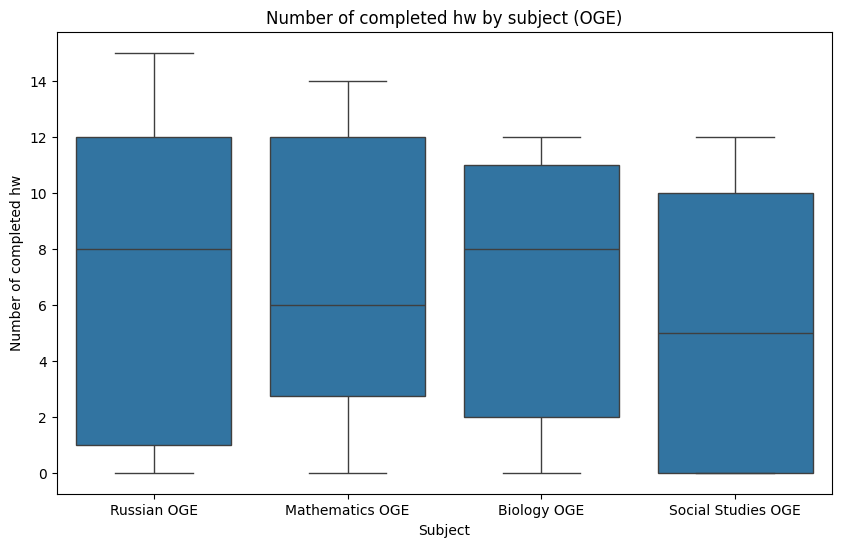

In [1816]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='subject_name', y='cnt_hw_done_per_course', data=student_df[student_df['subject_name'].isin(OGE_cols)])
plt.title('Number of completed hw by subject (OGE)')
plt.xlabel('Subject')
plt.ylabel('Number of completed hw')
plt.show()

Calculate the interquartile range (IQR) for each subject to compare variability in homework completion across subjects.

In [1817]:
def calculate_iqr(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    return IQR

iqr_per_subject = student_df.groupby('subject_name')['cnt_hw_done_per_course'].apply(calculate_iqr)
iqr_per_subject.sort_values(ascending=False)

subject_name
English               22.00
Literature            13.00
Biology               12.00
Chemistry             12.00
Russian OGE           11.00
History               10.00
Mathematics           10.00
Russian               10.00
Social Studies OGE    10.00
Mathematics OGE        9.25
Biology OGE            9.00
Social Studies         8.00
Physics                6.50
Basic Mathematics      0.00
Name: cnt_hw_done_per_course, dtype: float64

Subjects with a high IQR may have a more varied level of homework difficulty or may be influenced by external factors such as the curriculum, student preparation, student motivation, or teaching style.

Let's look at the data on those expelled and those not expelled:

In [1818]:
student_df_expelled = student_df[student_df['is_expelled'] == 1]
student_df_expelled['cnt_hw_done_per_course'].describe()

count       348.0
mean     1.008621
std      2.906305
min           0.0
25%           0.0
50%           0.0
75%           0.0
max          30.0
Name: cnt_hw_done_per_course, dtype: Float64

In [1819]:
student_df_not_expelled = student_df[~(student_df['is_expelled'] == 1)]
student_df_not_expelled['cnt_hw_done_per_course'].describe()

count      5533.0
mean     9.166817
std      6.655138
min           0.0
25%           4.0
50%           9.0
75%          13.0
max          33.0
Name: cnt_hw_done_per_course, dtype: Float64

From these data, we see that the average number of completed homework assignments for non-expelled students is 9, while for expelled students it is 1. The percentiles (25th, 50th, 75th) for the number of homework assignments for expelled students are 0, in contrast to non-expelled students, for whom the 25th percentile is 4. However, the maximum value for homework assignments among expelled students is 33, but this has already been discussed above.

In [1820]:
expelled_students = student_df_expelled['student_id'].nunique()
all_students = student_df['student_id'].nunique()
expelled_share = expelled_students / all_students * 100
print(f'Share of expelled students among all unique students: {expelled_share:.2f}%')

Share of expelled students among all unique students: 7.48%


In [1821]:
student_df_expelled_grouped = student_df_expelled.groupby('subject_type')['student_id'].agg('nunique').reset_index()
student_df_subject_type = student_df.groupby('subject_type')['student_id'].agg('nunique').reset_index()
student_df_expelled_grouped = student_df_expelled_grouped.merge(student_df_subject_type, how='inner', on='subject_type')
student_df_expelled_grouped = student_df_expelled_grouped.rename(columns={'student_id_x': 'expelled_cnt', 'student_id_y': 'all_studs'})
student_df_expelled_grouped['expelled_share(in %)'] = (student_df_expelled_grouped['expelled_cnt'] / student_df_expelled_grouped['all_studs']) * 100
student_df_expelled_grouped

,subject_type,expelled_cnt,all_studs,expelled_share(in %)
0,EGE,229,3197,7.162965
1,OGE,33,305,10.819672


In [1822]:
expelled_by_subject = (
    student_df_expelled
    .groupby(['subject_type', 'subject_name'])['student_id']
    .nunique()
    .reset_index(name='expelled_cnt')
)

all_students_by_subject = (
    student_df
    .groupby(['subject_type', 'subject_name'])['student_id']
    .nunique()
    .reset_index(name='all_students')
)

subject_expelled_stats = (
    expelled_by_subject
    .merge(all_students_by_subject, on=['subject_type', 'subject_name'], how='inner')
)

subject_expelled_stats['expelled_share_pct'] = (
    subject_expelled_stats['expelled_cnt']
    / subject_expelled_stats['all_students']
    * 100
)

subject_expelled_stats = subject_expelled_stats.sort_values(
    by=['subject_type', 'expelled_share_pct'],
    ascending=[True, False]
)

subject_expelled_stats

,subject_type,subject_name,expelled_cnt,all_students,expelled_share_pct
6,EGE,Mathematics,58,497,11.670020
0,EGE,Basic Mathematics,16,177,9.039548
1,EGE,Biology,26,313,8.306709
4,EGE,History,26,389,6.683805
2,EGE,Chemistry,8,155,5.161290
3,EGE,English,22,451,4.878049
5,EGE,Literature,21,473,4.439746
9,EGE,Social Studies,76,1780,4.269663
8,EGE,Russian,38,958,3.966597
7,EGE,Physics,4,116,3.448276


The expelled share appears to be higher in OGE-related subjects than in EGE-related subjects. This may be due to the fact that students preparing for the EGE and planning to enter university are generally more motivated and take a responsible approach to their preparation. Among EGE subjects, the highest number of expulsions is observed in mathematics (including the basic level), biology, and history.
For some specialized subjects, it can be assumed that students refused to take the exam and, as a result, dropped out of the course.


However, for compulsory subjects—for example, Russian language and mathematics (basic)—this explanation is not entirely justified. Perhaps the dropout rate in mathematics is higher because students believe they can prepare on their own.

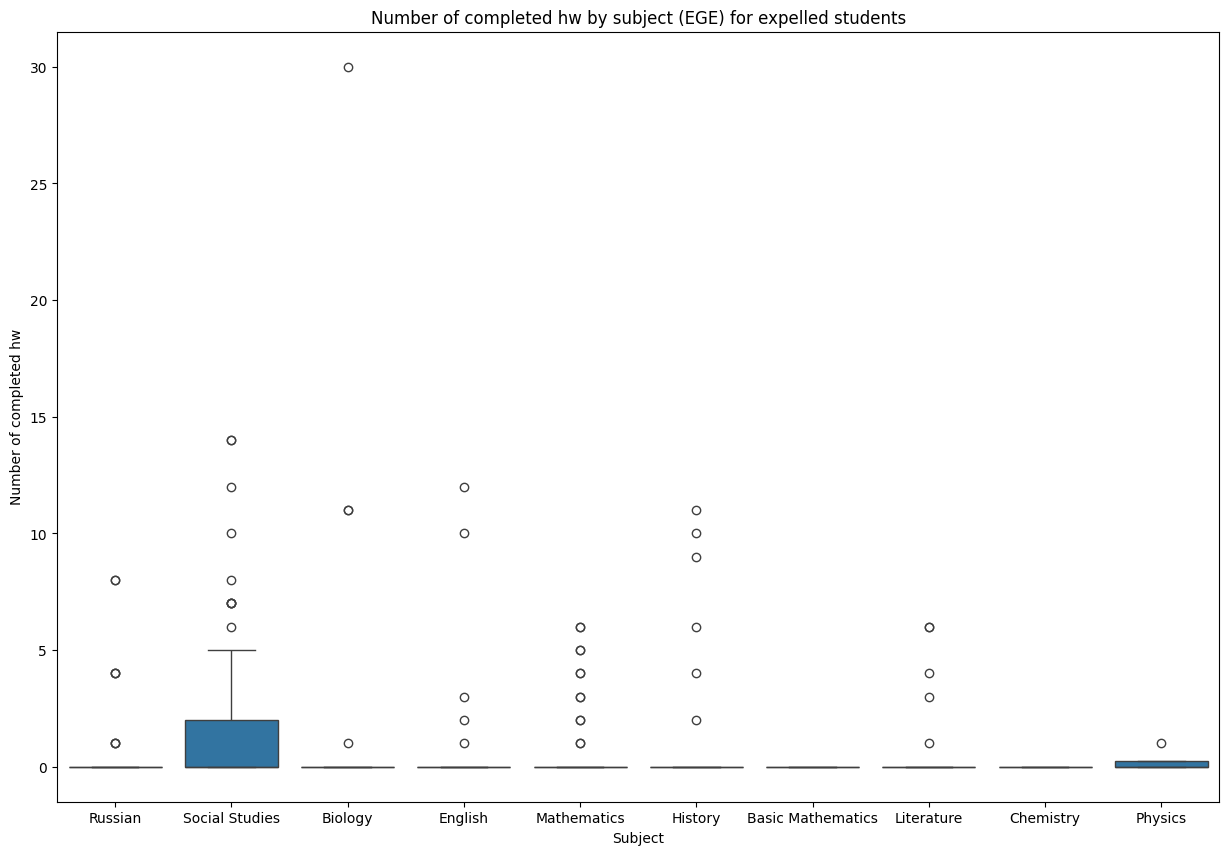

In [1823]:
plt.figure(figsize=(15, 10))
sns.boxplot(x='subject_name', y='cnt_hw_done_per_course', data=student_df_expelled[student_df_expelled['subject_type']=='EGE'])
plt.title('Number of completed hw by subject (EGE) for expelled students')
plt.xlabel('Subject')
plt.ylabel('Number of completed hw')
plt.show()

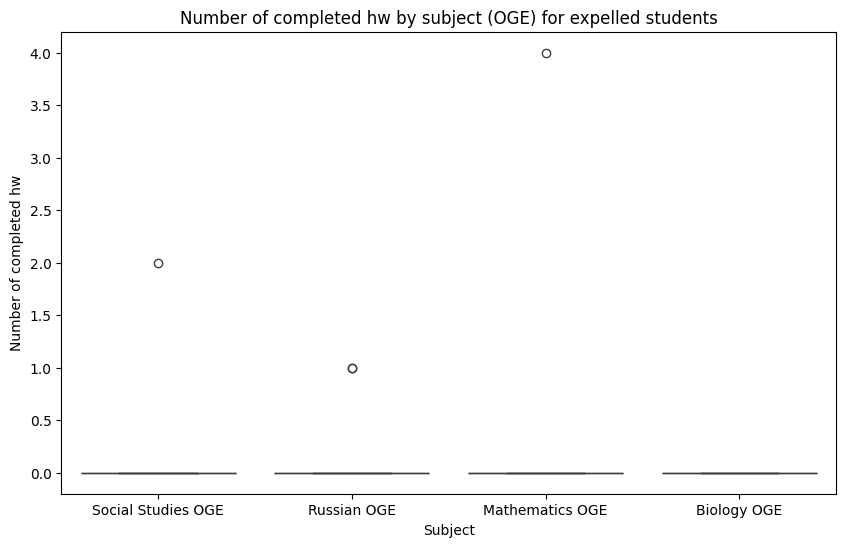

In [1824]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='subject_name', y='cnt_hw_done_per_course', data=student_df_expelled[student_df_expelled['subject_type']=='OGE'])
plt.title('Number of completed hw by subject (OGE) for expelled students')
plt.xlabel('Subject')
plt.ylabel('Number of completed hw')
plt.show()

Expelled students, as a rule, hardly did their homework.

Let's calculate the IQR for non-expelled students:

In [1825]:
iqr_per_subject_not_exp = student_df_not_expelled.groupby('subject_name')['cnt_hw_done_per_course'].apply(calculate_iqr)
iqr_per_subject_not_exp.sort_values(ascending=False)

subject_name
English               23.00
Chemistry             12.00
Literature            12.00
Biology               11.00
History               10.00
Mathematics OGE        9.00
Russian                9.00
Russian OGE            9.00
Social Studies OGE     9.00
Mathematics            8.00
Social Studies         8.00
Biology OGE            7.75
Physics                6.00
Basic Mathematics      0.00
Name: cnt_hw_done_per_course, dtype: float64

Let's plot boxplots for each subject for the students who weren't expelled to see if there are any outliers:

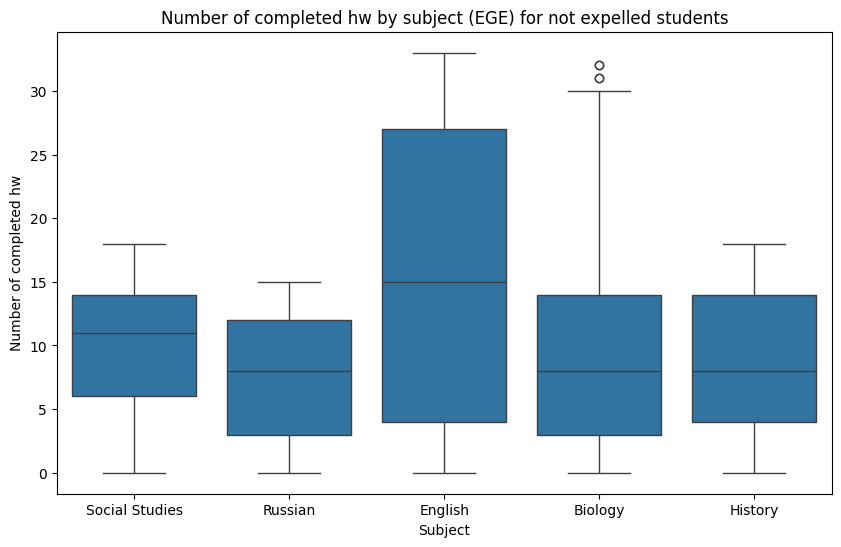

In [1826]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='subject_name', y='cnt_hw_done_per_course', data=student_df_not_expelled[student_df_not_expelled['subject_name'].isin(EGE_cols1)])
plt.title('Number of completed hw by subject (EGE) for not expelled students')
plt.xlabel('Subject')
plt.ylabel('Number of completed hw')
plt.show()

There are outliers in biology, let's look at this data:

In [1827]:
biology_iqr = calculate_iqr(student_df_not_expelled[student_df_not_expelled['subject_name'] == 'Biology']['cnt_hw_done_per_course'])
upper_bound = student_df_not_expelled[student_df_not_expelled['subject_name'] == 'Biology']['cnt_hw_done_per_course'].quantile(0.75) + 1.5*biology_iqr
student_df_not_expelled[(student_df_not_expelled['subject_name'] == 'Biology') & (student_df_not_expelled['cnt_hw_done_per_course'] > upper_bound)].sort_values(by='cnt_hw_done_per_course')

,course_id,course_name,subject_name,subject_type,course_type,course_start_date,student_id,student_last_name,city,is_expelled,student_start_date,available_months,cnt_hw_done_per_course
33,25,Годовой 2к25 стандарт,Biology,EGE,Annual,2024-09-17,10033,Боровинская,Екатеринбург,0,2024-07-26 14:08:17,2,31
1981,25,Годовой 2к25 стандарт,Biology,EGE,Annual,2024-09-17,25438,Meow,Краснодар,0,2024-09-16 19:25:03,2,31
331,25,Годовой 2к25 стандарт,Biology,EGE,Annual,2024-09-17,10276,Воронина,<NA>,0,2024-07-31 12:23:25,3,32
673,25,Годовой 2к25 стандарт,Biology,EGE,Annual,2024-09-17,10447,Кузнецова,Михайловка,0,2024-08-18 17:54:39,2,32


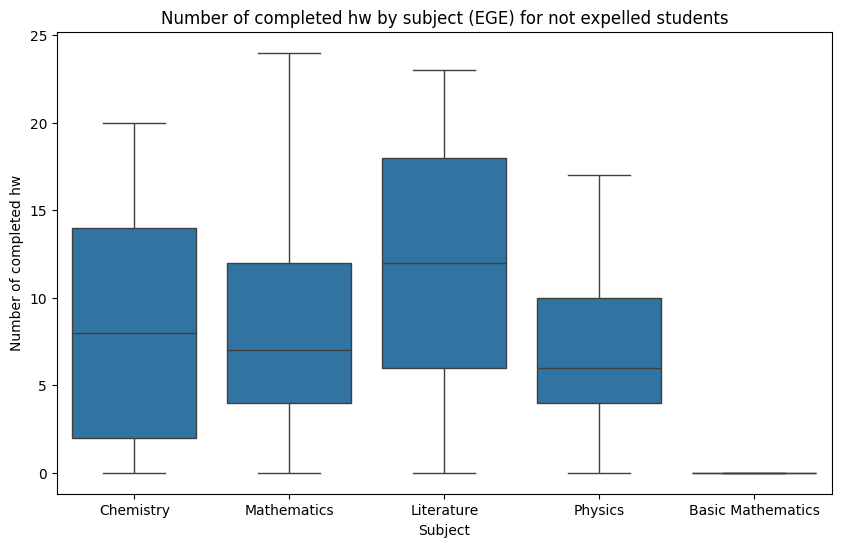

In [1828]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='subject_name', y='cnt_hw_done_per_course', data=student_df_not_expelled[student_df_not_expelled['subject_name'].isin(EGE_cols2)])
plt.title('Number of completed hw by subject (EGE) for not expelled students')
plt.xlabel('Subject')
plt.ylabel('Number of completed hw')
plt.show()

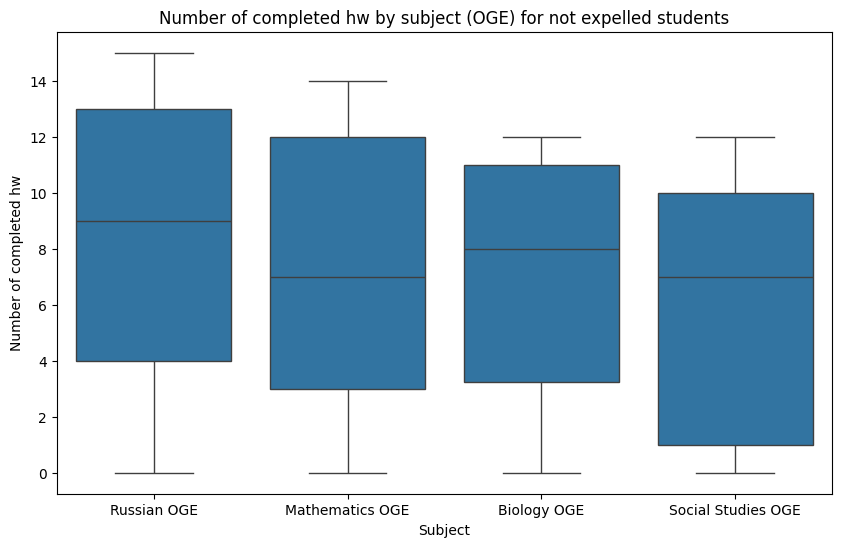

In [1829]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='subject_name', y='cnt_hw_done_per_course', data=student_df_not_expelled[student_df_not_expelled['subject_name'].isin(OGE_cols)])
plt.title('Number of completed hw by subject (OGE) for not expelled students')
plt.xlabel('Subject')
plt.ylabel('Number of completed hw')
plt.show()

Let's see if there are any students who don't have any available months of the course and who haven't been expelled:

In [1830]:
student_df[(student_df['available_months'] == 0)&(student_df['is_expelled'] == 0)].head()

,course_id,course_name,subject_name,subject_type,course_type,course_start_date,student_id,student_last_name,city,is_expelled,student_start_date,available_months,cnt_hw_done_per_course
3,17,Годовой 2к25 стандарт,English,EGE,Annual,2024-09-20,10003,Драгомирецкий,<NA>,0,2024-09-05 19:11:35,0,2
1818,39,Годовой курс 2к25 комбо (русский + обществозна...,Social Studies OGE,OGE,Annual,2024-09-15,25219,Лысов,Хабаровск,0,2024-09-16 13:45:20,0,0
3220,39,Годовой курс 2к25 комбо (русский + обществозна...,Social Studies OGE,OGE,Annual,2024-09-15,25975,Aix,Краснодар,0,2024-10-24 14:12:31,0,0
3228,39,Годовой курс 2к25 комбо (русский + обществозна...,Social Studies OGE,OGE,Annual,2024-09-15,28022,Зотова,Челябинск,0,2024-09-23 15:16:39,0,0
3239,39,Годовой курс 2к25 комбо (русский + обществозна...,Social Studies OGE,OGE,Annual,2024-09-15,28071,Павлов,Архангельск,0,2024-09-25 07:17:49,0,0


I wonder how it's possible that students aren't expelled, but they don't have any available classes. Could there be a technical error in the "available_months" column, causing it to show 0?

----------

Let's look at the distribution of the number of non-expelled students by city.

In [1831]:
city_student_count = (
    student_df_not_expelled
    .groupby('city', as_index=False)
    .agg(student_cnt=('student_id', 'nunique'))
    .sort_values('student_cnt', ascending=False)
)

city_student_count.describe(include='all')

,city,student_cnt
count,572,572.000000
unique,572,NaN
top,Москва,NaN
freq,1,NaN
mean,NaN,5.585664
std,NaN,19.602209
min,NaN,1.000000
25%,NaN,1.000000
50%,NaN,2.000000
75%,NaN,5.000000


Since there are so many cities, we will plot a graph for those cities where the number of students exceeds the 95th percentile:

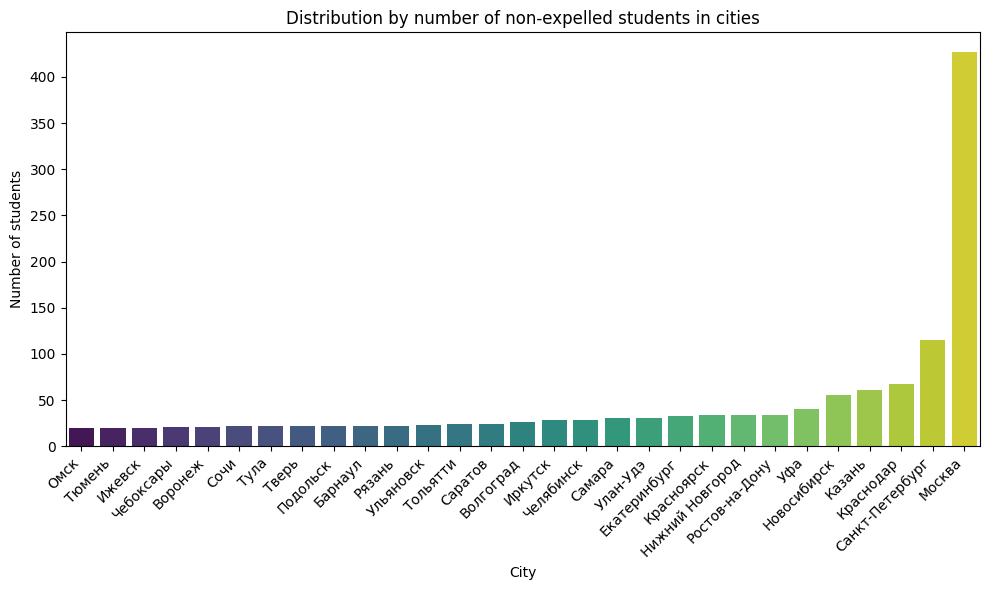

In [1832]:
city_student_count = city_student_count.sort_values(by='student_cnt')
city_student_count_more95 = city_student_count[city_student_count['student_cnt'] > np.percentile(city_student_count['student_cnt'], 95)]
plt.figure(figsize=(10, 6))
sns.barplot(x=city_student_count_more95['city'], y=city_student_count_more95['student_cnt'], palette='viridis')
plt.title('Distribution by number of non-expelled students in cities')
plt.xlabel('City')
plt.ylabel('Number of students')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

From the graph we see that the leading cities in terms of the number of students in them are Moscow, St. Petersburg, Krasnodar, Kazan, Novosibirsk, and Ufa.

In [1833]:
f"In these cities, the total number of students is {city_student_count[(city_student_count['city'].isin(['Уфа', 'Новосибирск', 'Казань', 'Краснодар', 'Санкт-Петербург', 'Москва']))]['student_cnt'].sum()} people"

'In these cities, the total number of students is 765 people'

In [1834]:
f"In other cities, the total number of students is {city_student_count[~(city_student_count['city'].isin(['Уфа', 'Новосибирск', 'Казань', 'Краснодар', 'Санкт-Петербург', 'Москва']))]['student_cnt'].sum()} people"

'In other cities, the total number of students is 2430 people'

## Wave distribution

The expelled share appears to be higher in OGE-related subjects than in EGE-related subjects.

In [1835]:
def assign_arrival_wave(student_dfr):
    days_diff = (student_dfr['student_start_date'] - student_dfr['course_start_date']).days
    
    if days_diff <= 0:
        return 0
    elif 1 <= days_diff <= 7:
        return 1
    elif 8 <= days_diff <= 14:
        return 2
    elif 15 <= days_diff <= 21:
        return 3
    elif 22 <= days_diff <= 28:
        return 4
    else:
        return 5

student_df['arrival_wave'] = student_df.apply(assign_arrival_wave, axis=1)


In [1836]:
student_df.groupby('course_name')['course_start_date'].nunique()


course_name
В погоне за пятеркой 2К25 стандарт                                  1
Годовой 2К25 стандарт с Катей                                       1
Годовой 2К25 стандарт с Машей                                       1
Годовой 2к25 минимал                                                4
Годовой 2к25 платинум                                               4
Годовой 2к25 стандарт                                               5
Годовой курс 2к25                                                   3
Годовой курс 2к25 комбо (биология + обществознание + математика)    1
Годовой курс 2к25 комбо (биология + русский + математика)           1
Годовой курс 2к25 комбо (русский + обществознание + математика)     1
Погоня за мечтой 2к25                                               6
Name: course_start_date, dtype: int64

In [1837]:
courses_with_issues = (
    student_df
    .groupby('course_name')['course_start_date']
    .nunique()
    .loc[lambda x: x > 1]
    .index
)

student_df[student_df['course_name'].isin(courses_with_issues)] \
    [['course_name', 'subject_name', 'course_start_date']] \
    .drop_duplicates() \
    .sort_values(by=['course_name', 'subject_name', 'course_start_date'])

,course_name,subject_name,course_start_date
1126,Годовой 2к25 минимал,Biology,2024-09-17
2480,Годовой 2к25 минимал,English,2024-09-20
1402,Годовой 2к25 минимал,History,2024-09-18
857,Годовой 2к25 минимал,Social Studies,2024-09-16
2688,Годовой 2к25 платинум,English,2024-09-20
2422,Годовой 2к25 платинум,Literature,2024-09-17
2158,Годовой 2к25 платинум,Russian,2024-09-21
2157,Годовой 2к25 платинум,Social Studies,2024-09-16
5,Годовой 2к25 стандарт,Biology,2024-09-17
4,Годовой 2к25 стандарт,Chemistry,2024-09-16


Since some courses have subjects with different start dates, we assign a wave to each student–course–subject record.

In [1838]:
arrival_waves = student_df[['student_id', 'student_last_name', 'course_name', 'subject_name','course_start_date', 'student_start_date', 'arrival_wave']]
arrival_waves.head()

,student_id,student_last_name,course_name,subject_name,course_start_date,student_start_date,arrival_wave
0,10001,Markova,Годовой 2к25 стандарт,Social Studies,2024-09-16,2024-07-25 18:04:20,0
1,10001,Markova,Годовой 2к25 стандарт,Russian,2024-09-21,2024-07-25 18:04:20,0
2,10002,Коваленко,Годовой 2к25 стандарт,Russian,2024-09-21,2024-07-25 18:07:04,0
3,10003,Драгомирецкий,Годовой 2к25 стандарт,English,2024-09-20,2024-09-05 19:11:35,0
4,10005,Гусев,Годовой 2к25 стандарт,Chemistry,2024-09-16,2024-07-26 05:38:40,0


In [1840]:
wave_distribution = (
    arrival_waves
    .groupby('arrival_wave')
    .size()
    .reset_index(name='records_cnt')
    .sort_values(by='arrival_wave')
)

wave_distribution['share_pct'] = (
    wave_distribution['records_cnt']
    / wave_distribution['records_cnt'].sum()
    * 100
).round(2)

wave_distribution

,arrival_wave,records_cnt,share_pct
0,0,2351,39.98
1,1,800,13.60
2,2,947,16.10
3,3,959,16.31
4,4,797,13.55
5,5,27,0.46


Most student–course–subject records belong to the early waves. Almost 40% of records fall into wave 0, meaning that a large share of students joined before or on the course start date. Waves 1–4 are distributed relatively evenly, each accounting for around 13–16% of records. Wave 5 is negligible (0.46%), which indicates that very few students join later than four weeks after the start date. 

This pattern suggests that students are more likely to enroll in advance, indicating proactive planning rather than last-minute course selection.